In [19]:
import cirq
import matplotlib.pyplot as plt

In [20]:
q0, q1, q2 = cirq.LineQubit.range(3)
a0, a1 = cirq.LineQubit.range(3, 5) #ancillas

circuit = cirq.Circuit()

#turning into the |+> state
circuit.append(cirq.H(q0))

#doing the encoding of one qubit onto three logical physicsal bits
circuit.append([cirq.CNOT(q0, q1), cirq.CNOT(q0, q2)])

print(circuit)

0: ───H───@───@───
          │   │
1: ───────X───┼───
              │
2: ───────────X───


In [21]:
#syndrome extraction
circuit.append([cirq.CNOT(q0, a0), cirq.CNOT(q1, a1)])
circuit.append(cirq.measure(a0, key='syndrome1'))

circuit.append([cirq.CNOT(q1, a1), cirq.CNOT(q2, a1)])
circuit.append(cirq.measure(a1, key='syndrome2'))

print("(PRE ANY ERROR CORRECTION)", circuit)

(PRE ANY ERROR CORRECTION)               ┌──┐   ┌──┐   ┌───────────────┐
0: ───H───@────@──────@──────────────────────────────────────────
          │    │      │
1: ───────X────┼@─────┼@─────────────────────────────────────────
               ││     ││
2: ────────────X┼─────┼┼───────────────────@─────────────────────
                │     ││                   │
3: ─────────────┼─────X┼─────M('syndrome1')┼─────────────────────
                │      │                   │
4: ─────────────X──────X───────────────────X────M('syndrome2')───
              └──┘   └──┘   └───────────────┘


In [22]:
sim = cirq.Simulator()

#defining syndrome for extraction
syndrome_result = sim.run(circuit, repetitions=1)

syndrome1 = int(syndrome_result.measurements['syndrome1'][0][0])
syndrome2 = int(syndrome_result.measurements['syndrome2'][0][0])

syndrome = (syndrome1, syndrome2)
print(syndrome)

(0, 0)


In [23]:
#error correction part
correction_operations = []

#no errors if (0, 0)
if syndrome == (1, 0):
    correction_operations.append(cirq.X(q0))
elif syndrome == (1, 1):
    correction_operations.append(cirq.X(q1))
elif syndrome == (0, 1):
    correction_operations.append(cirq.X(q2))

circuit.append(correction_operations)
circuit.append(cirq.measure(q0, q1, q2, key="result"))

print(circuit)

              ┌──┐   ┌──┐   ┌───────────────┐
0: ───H───@────@──────@─────────────────────────M('result')──────
          │    │      │                         │
1: ───────X────┼@─────┼@────────────────────────M────────────────
               ││     ││                        │
2: ────────────X┼─────┼┼───────────────────@────M────────────────
                │     ││                   │
3: ─────────────┼─────X┼─────M('syndrome1')┼─────────────────────
                │      │                   │
4: ─────────────X──────X───────────────────X────M('syndrome2')───
              └──┘   └──┘   └───────────────┘


Counter({0: 60, 7: 40})


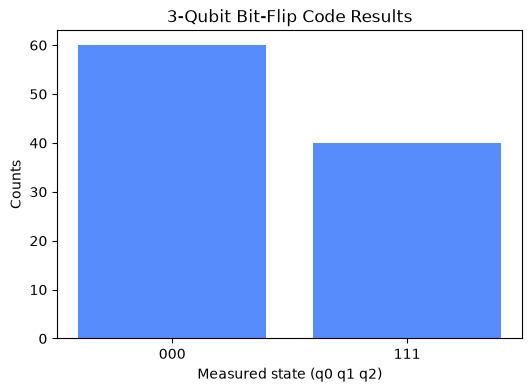

In [24]:
result = sim.run(circuit, repetitions=100)

histogram = result.histogram(key='result')
print(histogram)

labels = [format(k, '03b') for k in histogram.keys()]
counts = list(histogram.values())

# Plot
plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.xlabel('Measured state (q0 q1 q2)')
plt.ylabel('Counts')
plt.title('3-Qubit Bit-Flip Code Results')
plt.show()